# Clase 8 · Componentes principales

**Módulo 1: Introducción y fundamentos estadísticos** · Diplomado en Ciencia de Datos Aplicada · UTFSM

**Qué hacemos hoy.** Volvemos a los 263 jugadores de béisbol de la clase 7, cuyas 16 variables numéricas se correlacionan en bloques, y les aplicamos el análisis de componentes principales (PCA): calculamos las componentes, vemos cuánta variación explica cada una y de qué está hecha, dibujamos a los jugadores en el plano de las dos primeras y usamos las componentes para predecir el salario, como en la clase 7. Los datos del béisbol son del libro de James, Witten, Hastie y Tibshirani (2013), cuya sección 10.2 (pp. 374 a 385) es la lectura de esta clase.

**La idea de la clase:** muchas variables que se mueven juntas dicen pocas cosas. PCA encuentra cuántas cosas distintas dicen y cuánto pesa cada una, construyendo variables nuevas en vez de elegir entre las originales.

## 1. Preparación

Las bibliotecas de siempre, más dos piezas de **scikit-learn**: `StandardScaler` (la estandarización de la clase 7) y `PCA` (el cálculo de hoy).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn: estandarizar y calcular componentes principales
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")
%config InlineBackend.figure_format = "retina"
pd.options.display.float_format = "{:.3f}".format

In [2]:
# Datos locales del repositorio clonado
BASE = "datos/"
# Alternativa por URL, si no tiene el repositorio clonado:
# BASE = "https://raw.githubusercontent.com/daniopitz/diplomado-cdd/main/datos/"

## 2. Las 16 variables numéricas del béisbol

**Objetivo:** tener la tabla de la clase 7 con sus nombres en español, solo con las variables numéricas.

Los mismos pasos de la clase 7: se descartan los 59 jugadores sin salario y se traducen los nombres. Esta vez quedan fuera las tres variables categóricas (liga, división y liga de 1987): PCA trabaja con variables numéricas, y una dummy de 0 y 1 no tiene una escala en la que tenga sentido hablar de su variación junto a las demás.

In [3]:
jugadores = pd.read_csv(BASE + "clase07/hitters_islr.csv").dropna(subset=["Salary"])
nombres = {
    "AtBat": "turnos", "Hits": "hits", "HmRun": "jonrones", "Runs": "anotadas", "RBI": "impulsadas",
    "Walks": "bases_bolas", "Years": "temporadas", "CAtBat": "turnos_carrera", "CHits": "hits_carrera",
    "CHmRun": "jonrones_carrera", "CRuns": "anotadas_carrera", "CRBI": "impulsadas_carrera",
    "CWalks": "bases_bolas_carrera", "PutOuts": "outs_defensa", "Assists": "asistencias", "Errors": "errores",
}
X = jugadores.rename(columns=nombres)[list(nombres.values())].astype(float)
salario = jugadores["Salary"]   # miles de dólares en 1987; PCA no lo usa
print("jugadores:", len(X), "| variables:", X.shape[1])
X.head()

jugadores: 263 | variables: 16


,turnos,hits,jonrones,anotadas,impulsadas,bases_bolas,temporadas,turnos_carrera,hits_carrera,jonrones_carrera,anotadas_carrera,impulsadas_carrera,bases_bolas_carrera,outs_defensa,asistencias,errores
1,315.000,81.000,7.000,24.000,38.000,39.000,14.000,3449.000,835.000,69.000,321.000,414.000,375.000,632.000,43.000,10.000
2,479.000,130.000,18.000,66.000,72.000,76.000,3.000,1624.000,457.000,63.000,224.000,266.000,263.000,880.000,82.000,14.000
3,496.000,141.000,20.000,65.000,78.000,37.000,11.000,5628.000,1575.000,225.000,828.000,838.000,354.000,200.000,11.000,3.000
4,321.000,87.000,10.000,39.000,42.000,30.000,2.000,396.000,101.000,12.000,48.000,46.000,33.000,805.000,40.000,4.000
5,594.000,169.000,4.000,74.000,51.000,35.000,11.000,4408.000,1133.000,19.000,501.000,336.000,194.000,282.000,421.000,25.000


**Recordatorio de la clase 7.** Las variables se correlacionan en bloques: las de la carrera entre sí, y las de la temporada 1986 entre sí. El par más extremo son los turnos y los hits de la carrera:

In [4]:
X[["temporadas", "turnos_carrera", "hits_carrera", "anotadas_carrera"]].corr().round(3)

,temporadas,turnos_carrera,hits_carrera,anotadas_carrera
temporadas,1.000,0.916,0.898,0.877
turnos_carrera,0.916,1.000,0.995,0.983
hits_carrera,0.898,0.995,1.000,0.985
anotadas_carrera,0.877,0.983,0.985,1.000


## 3. Dos variables, una sola dirección

**Objetivo:** ver qué hace PCA en el caso más simple, con dos variables que dicen casi lo mismo.

Los turnos y los hits de la carrera tienen correlación 0,995. En un gráfico de dispersión los jugadores se ordenan a lo largo de una diagonal: casi toda la variación ocurre en esa dirección, y casi ninguna en la perpendicular. PCA encuentra esas dos direcciones. Primero se estandarizan las dos variables (media 0 y desviación 1), y luego `PCA().fit()` calcula las componentes.

In [5]:
dos = X[["turnos_carrera", "hits_carrera"]]

In [6]:
Z2 = StandardScaler().fit_transform(dos)   # cada columna con media 0 y desviación 1

In [7]:
pca2 = PCA().fit(Z2)


In [8]:
print("Variación explicada por cada componente:", pca2.explained_variance_ratio_.round(3))
print("Pesos de cada componente (una fila por componente):")
print(pca2.components_.round(3))

Variación explicada por cada componente: [0.998 0.002]
Pesos de cada componente (una fila por componente):
[[ 0.707  0.707]
 [ 0.707 -0.707]]


La primera componente explica el 99,8% de la variación y la segunda el 0,2%. Sus pesos son (0,707, 0,707) y (0,707, −0,707): la primera componente es la **suma** de las dos variables estandarizadas (dividida por √2, para que los pesos al cuadrado sumen 1) y la segunda es su **diferencia**. Los pesos son la **dirección** de cada eje nuevo: un paso de 1 a lo largo de la diagonal avanza 0,707 en turnos y 0,707 en hits (los dos catetos de 45°), y 0,707² + 0,707² = 1. Para estos jugadores, saber la suma es saber casi todo; la diferencia casi no varía.

**En la práctica, una componente es un puntaje ponderado por jugador**, como el puntaje ponderado de la admisión universitaria: cada variable entra con su peso y sale un número por jugador; `pca2.transform` lo calcula para cada uno:

In [9]:
puntajes2 = pca2.transform(Z2)  # cada jugador en las dos componentes

**De dónde sale el 99,8%.** La variación de una coordenada se mide con su varianza (clase 2). Las dos variables estandarizadas tienen varianza 1 y 1: la variación total de los datos es 2. Las dos coordenadas nuevas (los puntajes en las dos componentes) reparten esa misma variación total: sus varianzas también suman 2, y la proporción de cada una es lo que scikit-learn llama `explained_variance_ratio_`:

In [10]:
varianzas_originales = Z2.var(axis=0)        # turnos (z) y hits (z): 1 y 1
varianzas_nuevas = puntajes2.var(axis=0)     # 1.ª y 2.ª componente
print("varianzas originales:", varianzas_originales.round(3), "| total:", varianzas_originales.sum().round(3))
print("varianzas nuevas:    ", varianzas_nuevas.round(3), "| total:", varianzas_nuevas.sum().round(3))
print("proporción de cada componente:", (varianzas_nuevas / varianzas_nuevas.sum()).round(4))

varianzas originales: [1. 1.] | total: 2.0
varianzas nuevas:     [1.995 0.005] | total: 2.0
proporción de cada componente: [0.9975 0.0025]


**Qué guarda `pca2`.** `pca2.explained_variance_` es la varianza de cada coordenada nueva: cuánto se dispersan los jugadores a lo largo de cada eje. Da [2,003; 0,005]: son los 1,995 y 0,005 de arriba, con una diferencia chica porque numpy divide por n y scikit-learn por n − 1. `pca2.explained_variance_ratio_` es cada una dividida por la suma: 0,998 y 0,002, el 99,8% y el 0,2%. Y `np.sqrt(pca2.explained_variance_)` es la raíz, la desviación estándar de cada coordenada: 1,41 y 0,07.

In [11]:
print("varianza de cada coordenada nueva:", pca2.explained_variance_.round(3))
print("proporción del total:            ", pca2.explained_variance_ratio_.round(3))
print("desviación estándar (la raíz):   ", np.sqrt(pca2.explained_variance_).round(2))

varianza de cada coordenada nueva: [2.003 0.005]
proporción del total:             [0.998 0.002]
desviación estándar (la raíz):    [1.42 0.07]


### Con tres variables: tres ejes, y se decide cuántos conservar

Siempre salen tantos ejes (componentes) como variables; cuántos conservar es una decisión aparte. Para verlo se agrega una tercera variable que no tiene que ver con las otras dos: los outs de defensa. Cada jugador es ahora un punto en tres dimensiones y PCA entrega tres ejes:

In [12]:
tres = X[["turnos_carrera", "hits_carrera", "outs_defensa"]]
Z3 = StandardScaler().fit_transform(tres)
pca3 = PCA().fit(Z3)
pve3 = pca3.explained_variance_ratio_ * 100
print("variación explicada por cada componente:", pve3.round(1), "%")
print("acumulada:", np.cumsum(pve3).round(1), "%")


variación explicada por cada componente: [66.7 33.1  0.2] %
acumulada: [ 66.7  99.8 100. ] %


In [13]:
pd.DataFrame(pca3.components_, columns=tres.columns, index=["1.ª", "2.ª", "3.ª"]).round(2)

,turnos_carrera,hits_carrera,outs_defensa
1.ª,0.700,0.700,0.080
2.ª,-0.070,-0.050,1.000
3.ª,-0.710,0.710,-0.010


Tres variables, tres componentes. La primera junta turnos y hits (pesos iguales, 0,70 y 0,70) y explica el 66,7%; la segunda es casi solo la defensa (peso 1,00) y explica el 33,1%; la tercera es la diferencia entre turnos y hits (pesos de signo opuesto) y explica el 0,2%. Con dos componentes se conserva el 99,8%: la tercera se descarta. Si las tres variables dijeran cosas distintas, cada componente se llevaría cerca de un tercio y harían falta las tres.

## 4. Estandarizar y calcular las 16 componentes

**Objetivo:** tener las componentes de las 16 variables.

Como en la clase 7, cada variable se estandariza (media 0 y desviación 1, el puntaje z de la clase 2) antes de calcular las componentes, para que todas partan iguales:

In [14]:
escala = StandardScaler().fit(X)
Z = pd.DataFrame(escala.transform(X), columns=X.columns, index=X.index)   # las 16 variables estandarizadas
pca = PCA().fit(Z)
pve = pca.explained_variance_ratio_ * 100   # porcentaje de la variación que explica cada componente
print("variación explicada por las primeras componentes:", pve[:4].round(1), "%")

variación explicada por las primeras componentes: [45.3 25.7 10.8  5.4] %


## 5. Cuánta variación explica cada componente

**Objetivo:** decidir con cuántas componentes quedarse.

Con 16 variables hay 16 componentes, ordenadas de la que más variación explica a la que menos. La tabla muestra el porcentaje de cada una y el acumulado:

In [15]:
resumen = pd.DataFrame({
    "variación explicada (%)": pve,
    "acumulada (%)": np.cumsum(pve),
}, index=[f"componente {k}" for k in range(1, 17)])
resumen.round(1)

,variación explicada (%),acumulada (%)
componente 1,45.300,45.300
componente 2,25.700,71.000
componente 3,10.800,81.800
componente 4,5.400,87.200
componente 5,4.400,91.600
componente 6,3.200,94.800
componente 7,1.600,96.400
componente 8,1.200,97.500
componente 9,0.800,98.400
componente 10,0.600,99.000


La primera componente explica el 45,3%; la segunda, el 25,7%; la tercera, el 10,8%. Las barras caen fuerte hasta la tercera y desde la cuarta quedan casi planas (5,4%, 4,4%, 3,2%...): ese quiebre se llama el **codo**, y se conservan las componentes de antes del codo, que son las que explican mucho cada una; aquí, dos o tres. La curva acumulada dice cuánto se conserva con cada cantidad: con dos, el 71%; con tres, el 82%; con cinco, el 92%; con diez, el 99%. Conservar diez de dieciséis casi no reduce nada. No hay una regla objetiva: depende de cuánta variación se acepte perder y para qué se usen las componentes (James et al., 2013, p. 384). El gráfico de barras se llama *scree plot*:

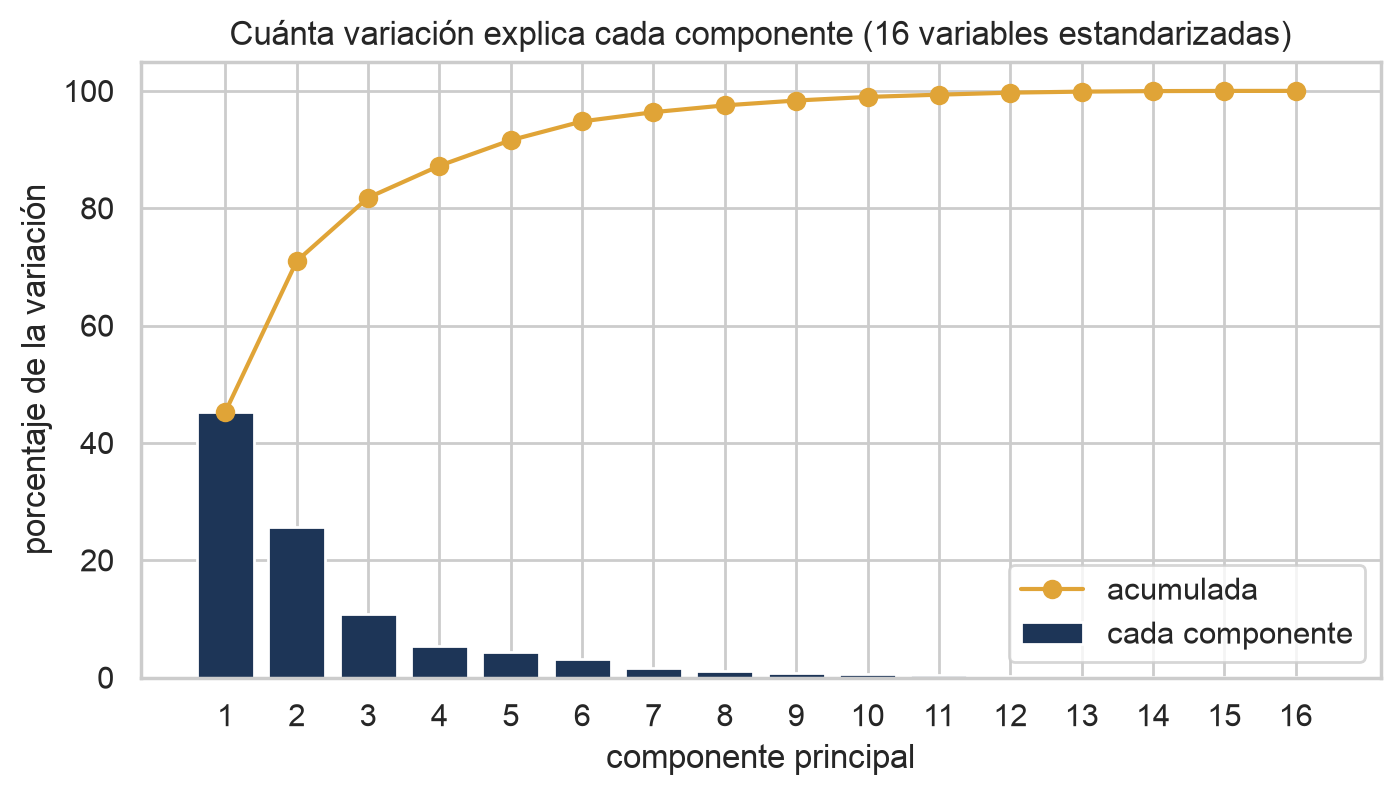

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
k = np.arange(1, 17)
ax.bar(k, pve, color="#1D3557", label="cada componente")
ax.plot(k, np.cumsum(pve), color="#E0A437", marker="o", label="acumulada")
ax.set_xticks(k)
ax.set_xlabel("componente principal")
ax.set_ylabel("porcentaje de la variación")
ax.set_title("Cuánta variación explica cada componente (16 variables estandarizadas)")
ax.legend()
plt.show()

## 6. De qué está hecha cada componente: los pesos

**Objetivo:** leer las dos primeras componentes.

Cada componente es un puntaje ponderado de las 16 variables estandarizadas, y `pca.components_` guarda los pesos (una fila por componente, una columna por variable). Los pesos son la dirección del eje: cuánto avanza cada variable en un paso de 1 a lo largo de él; por eso sus cuadrados suman 1, como 0,707² + 0,707² con dos variables. El signo de una componente es arbitrario: cambiarlo a toda la fila no cambia nada (James et al., 2013, p. 382). Aquí se usan tal como los entrega scikit-learn; si en otro computador salen con el signo cambiado, la lectura es la misma.

In [17]:
cargas = pd.DataFrame(pca.components_[:3].T, index=X.columns, columns=["PC1", "PC2", "PC3"])   # una fila por variable, una columna por componente
cargas.round(2)

,PC1,PC2,PC3
turnos,0.200,0.390,0.070
hits,0.190,0.380,0.050
jonrones,0.200,0.240,-0.340
anotadas,0.200,0.380,-0.060
impulsadas,0.230,0.320,-0.170
bases_bolas,0.210,0.240,-0.070
temporadas,0.290,-0.260,0.100
turnos_carrera,0.330,-0.190,0.130
hits_carrera,0.330,-0.180,0.120
jonrones_carrera,0.320,-0.120,-0.120


In [18]:
# los pesos al cuadrado suman 1 en cada componente: el paso a lo largo del eje mide 1
(cargas ** 2).sum().round(3)

PC1   1.000
PC2   1.000
PC3   1.000
dtype: float64

**Primera componente (45%):** las siete variables de la carrera pesan casi lo mismo (0,29 a 0,34), las seis de la temporada 1986 la mitad (0,19 a 0,23) y las tres de defensa casi nada. Mide cuánta carrera lleva el jugador.

**Segunda componente (26%):** la temporada 1986 pesa positivo (0,24 a 0,39) y la carrera negativo (−0,12 a −0,26). Separa a quien rindió este año más de lo que dice su carrera de quien rindió menos.

**Tercera componente (11%):** casi solo asistencias (0,65) y errores (0,57): la defensa, que no entraba en las dos primeras.

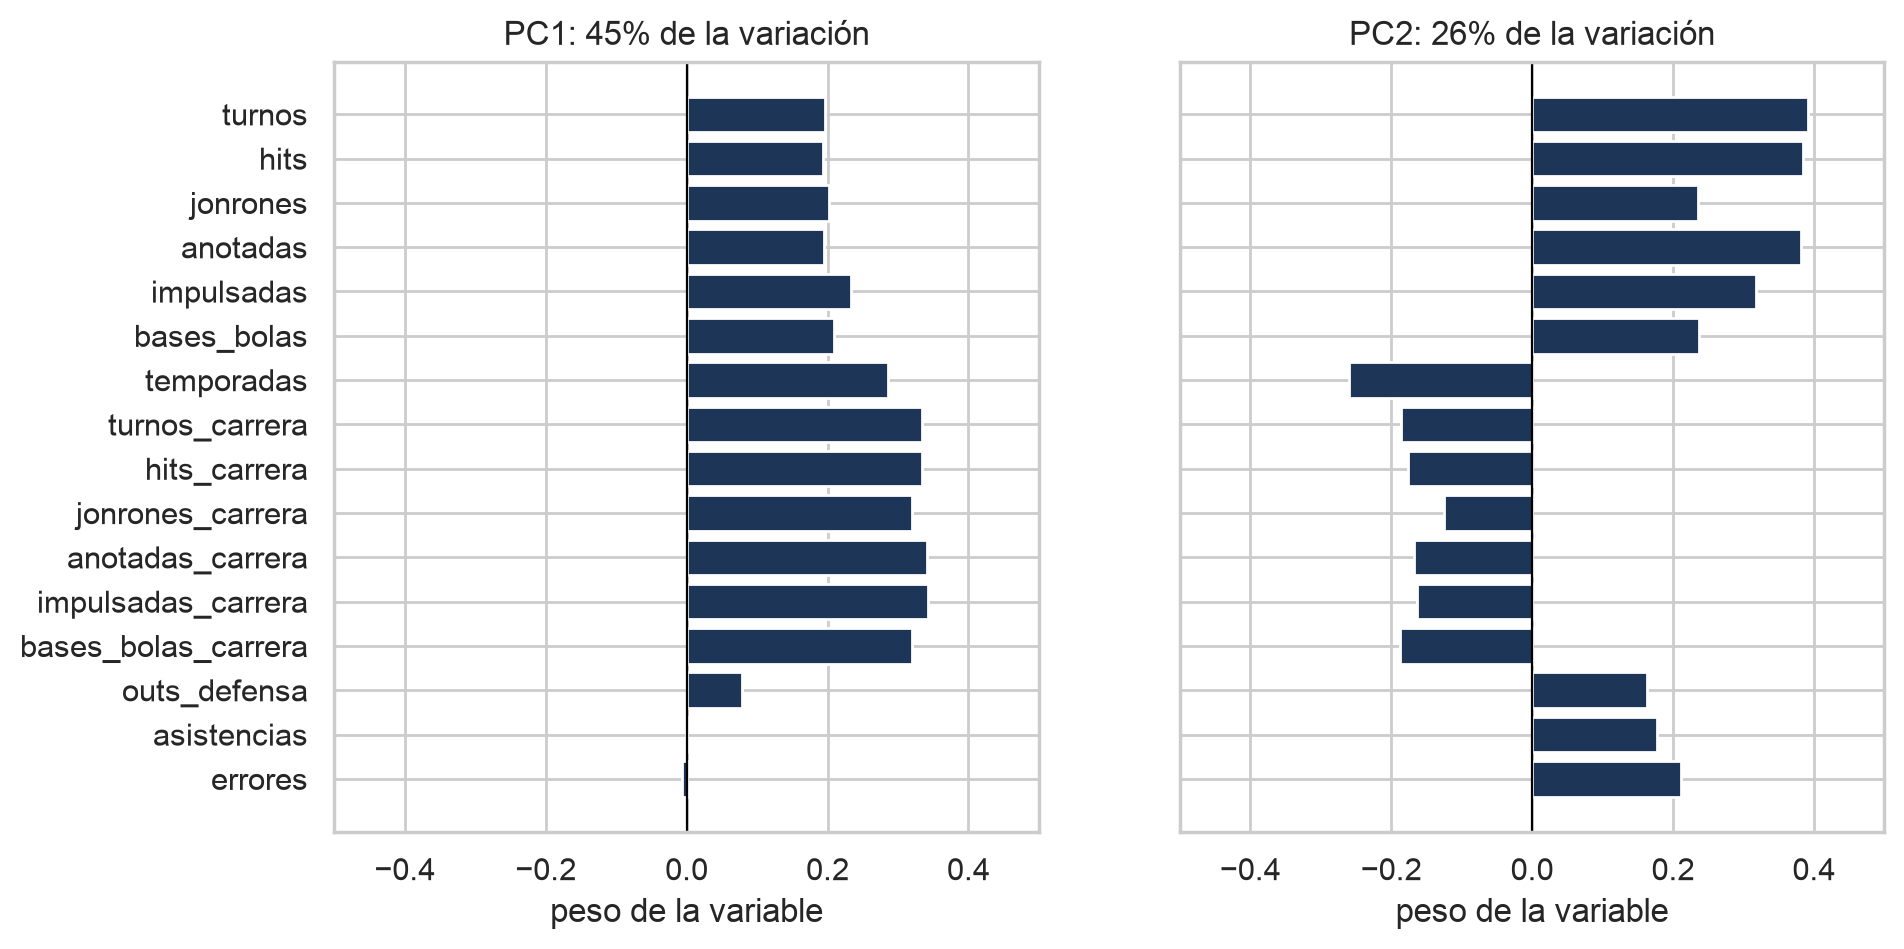

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
for ax, pc in zip(axes, ["PC1", "PC2"]):
    ax.barh(cargas.index, cargas[pc], color="#1D3557")
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlim(-0.5, 0.5)
    ax.set_title(f"{pc}: {pve[int(pc[-1]) - 1]:.0f}% de la variación")
    ax.set_xlabel("peso de la variable")
axes[0].invert_yaxis()
plt.show()

## 7. Los jugadores en el plano de las dos componentes

**Objetivo:** usar las componentes como variables nuevas.

`pca.transform(Z)` calcula, para cada jugador, su valor en cada componente (los *puntajes*). Con las dos primeras se puede dibujar a los 263 jugadores en un solo gráfico, en vez de los 120 gráficos de dispersión que permiten 16 variables. El color es el salario, que PCA no usó:

In [20]:
puntajes = pca.transform(Z)   # cada jugador en las 16 componentes
plano = pd.DataFrame({"PC1": puntajes[:, 0], "PC2": puntajes[:, 1], "salario": salario.values})
plano.head()

,PC1,PC2,salario
0,0.135,-1.648,475.000
1,0.333,2.337,480.000
2,3.552,-0.646,500.000
3,-2.491,0.336,91.500
4,0.965,1.520,750.000


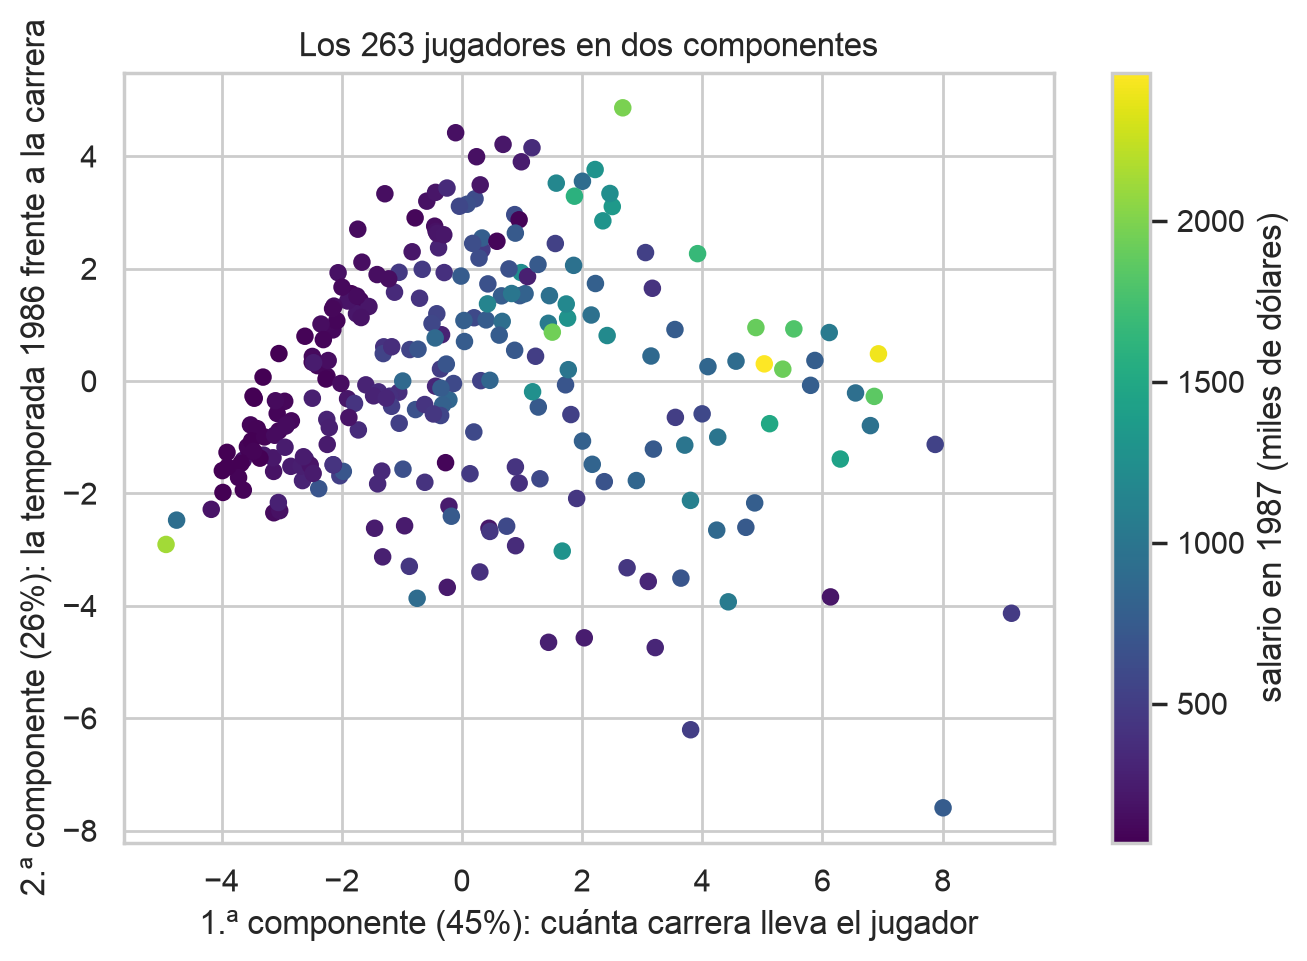

In [21]:
fig, ax = plt.subplots(figsize=(7.5, 5))
puntos = ax.scatter(plano["PC1"], plano["PC2"], c=plano["salario"], cmap="viridis", s=28)
fig.colorbar(puntos, ax=ax, label="salario en 1987 (miles de dólares)")
ax.set_xlabel(f"1.ª componente ({pve[0]:.0f}%): cuánta carrera lleva el jugador")
ax.set_ylabel(f"2.ª componente ({pve[1]:.0f}%): la temporada 1986 frente a la carrera")
ax.set_title("Los 263 jugadores en dos componentes")
plt.show()

In [22]:
print("correlación del salario con la 1.ª componente:", round(plano["PC1"].corr(plano["salario"]), 2))
print("correlación del salario con la 2.ª componente:", round(plano["PC2"].corr(plano["salario"]), 2))

correlación del salario con la 1.ª componente: 0.64
correlación del salario con la 2.ª componente: 0.11


El salario crece hacia la derecha (correlación 0,64 con la primera componente) y casi nada hacia arriba (0,11 con la segunda): la carrera pesa en el salario y la última temporada, poco. Es una lectura que en la clase 7 exigía mirar 16 coeficientes; aquí está en dos ejes. Con las componentes como variables nuevas se puede además ajustar una regresión del salario sobre dos o tres de ellas (regresión sobre componentes principales; James et al., 2013, sección 6.3.1).

## 8. El salario con pocas componentes

**Objetivo:** comparar, en datos de prueba, la regresión del salario con las 16 variables y la regresión con unas pocas componentes.

En la clase 7, mínimos cuadrados con las 19 variables (las 16 numéricas y las 3 dummies) tuvo un error de prueba (RMSE) de 342 mil dólares, Ridge 316 y Lasso 325, con un reparto de 131 jugadores de entrenamiento y 132 de prueba. Aquí se usa el mismo reparto y solo las 16 numéricas, y se comparan dos modelos: **mínimos cuadrados con las 16 variables** y **mínimos cuadrados con las primeras componentes** en vez de las variables.

**Primero, mínimos cuadrados con las 16 variables.** La estandarización se ajusta solo con los jugadores de entrenamiento y con esa misma escala se transforman los de prueba:

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_ent, X_pru, y_ent, y_pru = train_test_split(X, salario, test_size=0.5, random_state=1)   # el reparto de la clase 7
escala_ent = StandardScaler().fit(X_ent)
Z_ent = escala_ent.transform(X_ent)   # las 16 variables estandarizadas, entrenamiento
Z_pru = escala_ent.transform(X_pru)   # prueba, con la misma escala

def rmse(real, predicho):
    return np.sqrt(np.mean((real - predicho) ** 2))

mco_16 = LinearRegression().fit(Z_ent, y_ent)
print("mínimos cuadrados con las 16 variables | RMSE prueba:", round(rmse(y_pru, mco_16.predict(Z_pru))),
      "| RMSE entrenamiento:", round(rmse(y_ent, mco_16.predict(Z_ent))))

mínimos cuadrados con las 16 variables | RMSE prueba: 347 | RMSE entrenamiento: 307


**Ahora, mínimos cuadrados con dos componentes.** PCA también se ajusta solo con los jugadores de entrenamiento, y los de prueba se proyectan sobre esos mismos ejes. El modelo tiene dos entradas en vez de dieciséis:

In [24]:
pca_ent = PCA().fit(Z_ent)
P_ent = pca_ent.transform(Z_ent)   # los puntajes de entrenamiento: 16 columnas, una por componente
P_pru = pca_ent.transform(Z_pru)   # los de prueba, sobre los mismos ejes

mco_2pc = LinearRegression().fit(P_ent[:, :2], y_ent)   # solo las dos primeras componentes
print("mínimos cuadrados con 2 componentes    | RMSE prueba:", round(rmse(y_pru, mco_2pc.predict(P_pru[:, :2]))),
      "| RMSE entrenamiento:", round(rmse(y_ent, mco_2pc.predict(P_ent[:, :2]))))
print(f"salario = {mco_2pc.intercept_:.0f} + {mco_2pc.coef_[0]:.1f} × (1.ª componente) + {mco_2pc.coef_[1]:.1f} × (2.ª componente)")

mínimos cuadrados con 2 componentes    | RMSE prueba: 321 | RMSE entrenamiento: 365
salario = 533 + 112.8 × (1.ª componente) + 30.1 × (2.ª componente)


**Los dos modelos, lado a lado:**

In [25]:
comparacion = pd.DataFrame({
    "entradas del modelo": [16, 2],
    "RMSE entrenamiento": [rmse(y_ent, mco_16.predict(Z_ent)), rmse(y_ent, mco_2pc.predict(P_ent[:, :2]))],
    "RMSE prueba": [rmse(y_pru, mco_16.predict(Z_pru)), rmse(y_pru, mco_2pc.predict(P_pru[:, :2]))],
}, index=["mínimos cuadrados, 16 variables", "mínimos cuadrados, 2 componentes"])
comparacion.round(0).astype(int)

,entradas del modelo,RMSE entrenamiento,RMSE prueba
"mínimos cuadrados, 16 variables",16,307,347
"mínimos cuadrados, 2 componentes",2,365,321


Con las 16 variables el modelo ajusta mejor a los jugadores que vio (307) y se equivoca más en los que no vio (347). Con dos componentes pasa lo contrario: ajusta peor en entrenamiento (365) y mejor en prueba (321). Es el mismo sobreajuste de la clase 7: con 16 entradas y 131 jugadores, el modelo se ajusta al azar de la muestra. Dos números por jugador (cuánta carrera lleva, y cómo rindió este año frente a su carrera) predicen el salario mejor que las 16 variables y casi tan bien como Ridge (316): por cada unidad más en la primera componente, unos 113 mil dólares más de salario; por cada unidad en la segunda, unos 30 mil.

**¿Y con otro número de componentes?** El mismo cálculo con las primeras 1, 2, 3, ..., 16 componentes:

In [26]:
errores = []
for k in range(1, 17):   # con las primeras k componentes
    modelo = LinearRegression().fit(P_ent[:, :k], y_ent)
    errores.append({"componentes": k, "RMSE entrenamiento": rmse(y_ent, modelo.predict(P_ent[:, :k])),
                    "RMSE prueba": rmse(y_pru, modelo.predict(P_pru[:, :k]))})
pd.DataFrame(errores).set_index("componentes").round(0).astype(int)

,RMSE entrenamiento,RMSE prueba
componentes,,
1,370,321
2,365,321
3,365,321
4,347,336
5,345,335
6,344,341
7,343,343
8,341,340
9,340,343


Con 1, 2 o 3 componentes el error de prueba es 321. Desde la cuarta sube mientras el de entrenamiento baja: las componentes que siguen agregan ajuste al azar de la muestra, no información. La última fila, con las 16 componentes, da lo mismo que las 16 variables (347 y 307): son los mismos datos con los ejes girados, así que el modelo es el mismo. Esto es la regresión sobre componentes principales (James et al., 2013, sección 6.3.1).

## 9. Cuándo conviene y cuándo no

- **Conviene** con muchas variables numéricas que se correlacionan en bloques, para mirarlas en un plano o para entregarle a un modelo menos entradas.
- **No aporta** si las variables son pocas y distintas entre sí: no hay nada que resumir.
- Las **variables categóricas** (dummies) no entran bien en el cálculo; se dejan fuera o se tratan aparte.
- Las componentes **no siempre tienen una lectura clara**. Aquí sí, pero no está garantizado.
- Es **no supervisado**: la dirección de más variación no es necesariamente la que mejor predice la respuesta. Ridge y Lasso eligen mirando Y; PCA no la mira.

### Ejercicio

1. Con la tabla `resumen` de la sección 5, ¿cuántas componentes hacen falta para superar el 90% de la variación de las 16 variables?
2. Repita el cálculo (estandarizar, ajustar PCA, variación explicada, pesos y puntajes) solo con las seis variables de la temporada 1986 (`turnos`, `hits`, `jonrones`, `anotadas`, `impulsadas`, `bases_bolas`). ¿Qué porcentaje explica la primera componente? ¿Qué variable pesa distinto de las demás en la segunda?

In [27]:
# Ejercicio 1

# Ejercicio 2


---

**Cierre del módulo.** Este es el último notebook del módulo 1. PCA vuelve, junto con clustering, en el módulo 3 (Machine Learning para la Toma de Decisiones). El informe escrito de avance se entrega el viernes 25 de septiembre por el Aula.